In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

c:\Users\limon\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


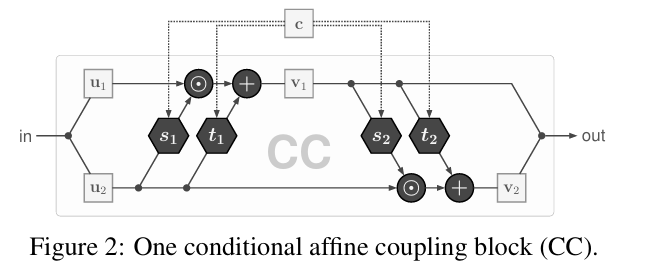

**FORWARD**:

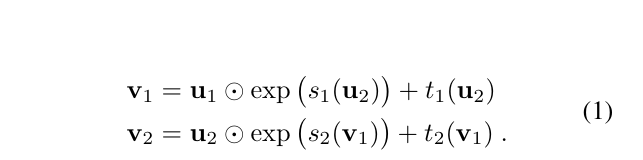

**BACKWARD**:

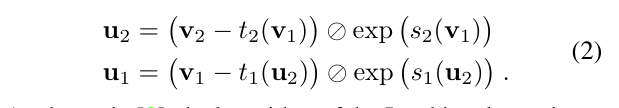

*шаблоны для s1, s2, t1, t2*

In [2]:
# базовый шаблон
class st_net(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), #
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], output_dim),
            nn.Tanh() 
        )
    
    def forward(self, input):
        return self.net(input)  

# линейное преобразование
class LinearNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), #
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.Linear(hidden_dims[1], output_dim),
        )
    
    def forward(self, input):
        return self.net(input)  

In [3]:
# собственно, сама сеть
class INN(nn.Module):
    def __init__(self, input_dim1, input_dim2, 
                hidden_dims_s1 = [64, 64], hidden_dims_s2 = [64, 64],
                hidden_dims_t1 = [64, 64], hidden_dims_t2 = [64, 64]):
        
        super().__init__()
        self.input = None
        self.input_dim1 = input_dim1
        self.input_dim2 = input_dim2

        self.u1 = None
        self.u2 = None
        self.v1 = None
        self.v2 = None

        self.s1_net = st_net(input_dim2, hidden_dims_s1, input_dim1)
        self.s2_net = st_net(input_dim1, hidden_dims_s2, input_dim2)
        self.t1_net = st_net(input_dim2, hidden_dims_t1, input_dim1)
        self.t2_net = st_net(input_dim1, hidden_dims_t2, input_dim2)


    def forward(self, input, reverse=False):
        if not reverse:  # Прямое преобразование

            self.input = input
            self.u1 = self.input[:, :self.input_dim1]
            self.u2 = self.input[:, self.input_dim1:]

            s1 = self.s1_net(self.u2)
            t1 = self.t1_net(self.u2)
            v1 = self.u1 * torch.exp(s1) + t1

            s2 = self.s2_net(v1)
            t2 = self.t2_net(v1)
            v2 = self.u2 * torch.exp(s2) + t2

            self.v1 = v1
            self.v2 = v2
            output = torch.cat((v1, v2), dim=1)

            return output
        
        else: # Обратный проход
            
            s2 = self.s2_net(self.v1)
            t2 = self.t2_net(self.v1)
            u2 = (self.v2 - t2) / torch.exp(s2)

            s1 = self.s1_net(u2)
            t1 = self.t1_net(u2)
            u1 = (self.v1 - t1) / torch.exp(s1)

            rerv_input = torch.cat((u1, u2), dim=1)

            return rerv_input

Проверим, что сеть "обращается"

In [4]:
def test_invertible_network():
    batch_size = 3
    model = INN(input_dim1=3, input_dim2=7)
    x = torch.randn(batch_size, 10)
    z = model(x)
    x_rev = model(z, reverse=True)
    print(f" x_fwd ={x}, \n x_rev ={x_rev}, \n z = {z}")
    reconstruction_error = F.mse_loss(x, x_rev)
    
    return model, reconstruction_error

In [5]:
model, reconstruction_error = test_invertible_network()
print(f"Reconstruction error: {reconstruction_error}")


 x_fwd =tensor([[ 0.4444,  0.2643,  0.4234,  1.8109,  1.1689,  1.1752,  1.3221,  1.6938,
         -1.0169,  0.5889],
        [ 0.4927,  0.1695, -0.2272,  0.0661,  0.9325,  1.8668, -0.4389, -0.9768,
          2.3013,  0.1947],
        [ 1.7990, -0.8815,  0.7161, -1.1772, -1.4298, -0.9322, -1.2526, -1.6575,
          0.4678,  1.2983]]), 
 x_rev =tensor([[ 0.4444,  0.2643,  0.4234,  1.8109,  1.1689,  1.1752,  1.3221,  1.6938,
         -1.0169,  0.5889],
        [ 0.4927,  0.1695, -0.2272,  0.0661,  0.9325,  1.8668, -0.4389, -0.9768,
          2.3013,  0.1947],
        [ 1.7990, -0.8815,  0.7161, -1.1772, -1.4298, -0.9322, -1.2526, -1.6575,
          0.4678,  1.2983]], grad_fn=<CatBackward0>), 
 z = tensor([[ 0.4271,  0.1785,  0.6354,  1.8413,  1.1500,  1.3599,  1.1780,  1.3934,
         -0.7185,  0.6489],
        [ 0.4773,  0.2567, -0.0545, -0.0609,  0.8686,  2.0536, -0.2901, -0.9437,
          2.0510,  0.2967],
        [ 1.5836, -0.7957,  0.7027, -1.1718, -1.7685, -0.9317, -0.8712, -1.40

In [6]:
print(model)

INN(
  (s1_net): st_net(
    (net): Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=3, bias=True)
      (5): Tanh()
    )
  )
  (s2_net): st_net(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=7, bias=True)
      (5): Tanh()
    )
  )
  (t1_net): st_net(
    (net): Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=3, bias=True)
      (5): Tanh()
    )
  )
  (t2_net): st_net(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): ReLU()


Тест на `"Искуственных данных"` 

In [7]:
X_dataset = samples =  torch.distributions.Uniform(0, 1).sample((10000, 10))
X_dataset   

tensor([[0.2787, 0.8557, 0.1527,  ..., 0.3124, 0.0901, 0.0580],
        [0.7848, 0.8807, 0.9037,  ..., 0.0935, 0.7296, 0.9682],
        [0.7453, 0.6198, 0.4693,  ..., 0.4731, 0.7974, 0.5478],
        ...,
        [0.4225, 0.4350, 0.8973,  ..., 0.3500, 0.7594, 0.7772],
        [0.8463, 0.6896, 0.7138,  ..., 0.9053, 0.8301, 0.2523],
        [0.7131, 0.2340, 0.8172,  ..., 0.8782, 0.0613, 0.1085]])

In [ ]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, data):   
        self.labels = data
        self.targets = 2 * data + tor
    
    def __len__(self):
        return len(self.labels)
    
    def 

SyntaxError: incomplete input (2821352535.py, line 5)